# Exploratory Data Analysis (EDA) - Vehicle Price Prediction

This notebook performs Exploratory Data Analysis on the Sri Lanka Vehicle Price Dataset to understand the data distribution, correlations, and key factors influencing vehicle prices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
try:
    df = pd.read_csv('data/sri_lanka_car_price_dataset.csv')
    print("Dataset Loaded Successfully")
    print(df.head())
except FileNotFoundError:
    print("Error: 'data/sri_lanka_car_price_dataset.csv' not found. Please check the path.")

Dataset Loaded Successfully
   Unnamed: 0 Brand Model   YOM  Engine (cc)       Gear Fuel Type  \
0           0  AUDI    A1  2016        990.0  Automatic    Petrol   
1           1  AUDI    A1  2017       1000.0  Automatic    Petrol   
2           2  AUDI    A1  2018       1000.0  Automatic    Petrol   
3           3  AUDI    A1  2017       1000.0  Automatic    Petrol   
4           4  AUDI    A1  2017       1000.0  Automatic    Petrol   

   Millage(KM)                    Town        Date     Leasing Condition  \
0      99000.0                 Gampaha  2025-02-05  No Leasing      USED   
1      88000.0                 Colombo  2025-01-14  No Leasing      USED   
2      77000.0  Dehiwala-Mount-Lavinia  2025-01-23  No Leasing      USED   
3      88000.0                 Negombo  2024-12-21  No Leasing      USED   
4      88000.0                 Colombo  2024-12-21  No Leasing      USED   

  AIR CONDITION POWER STEERING POWER MIRROR POWER WINDOW  Price  
0     Available      Available    

In [3]:
# Preprocessing Logic (similar to src/preprocessing.py)

# 1. Handle Missing Values and Date
# Rename columns to standard names for easier processing
df.rename(columns={
    'YOM': 'Manufacturer Year',
    'Brand': 'brand',
    'Model': 'model',
    'Gear': 'Transmission', 
    'Fuel Type': 'Fuel_Type',
    'Millage(KM)': 'mileage' 
}, inplace=True)

df['Manufacturer Year'] = pd.to_numeric(df['Manufacturer Year'], errors='coerce')
# If Model Year exists, use it, otherwise create it or ignore
if 'Model Year' in df.columns:
    df['Model Year'] = pd.to_numeric(df['Model Year'], errors='coerce')
    # Fill missing year with model year if needed
    df['Manufacturer Year'] = df['Manufacturer Year'].fillna(df['Model Year'])

# 2. Convert Price to Numeric
if df['Price'].dtype == object:
    df['Price'] = df['Price'].astype(str).str.replace(',', '').str.replace('Rs. ', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Detect if price is in Lakhs (e.g. 100.0) and convert
if df['Price'].median() < 10000:
    print("Detected price appear to be in Lakhs. Adjusting...")
    df['Price'] = df['Price'] * 100000

# 3. Convert Mileage
if df['mileage'].dtype == object:
    df['mileage'] = df['mileage'].str.replace(' km', '').str.replace(',', '')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

print("Data shape after basic cleaning:", df.shape)
df.dropna(subset=['Price', 'Manufacturer Year'], inplace=True)
print("Data shape after dropping missing Price/Year:", df.shape)

Detected price appear to be in Lakhs. Adjusting...
Data shape after basic cleaning: (9788, 17)
Data shape after dropping missing Price/Year: (9788, 17)


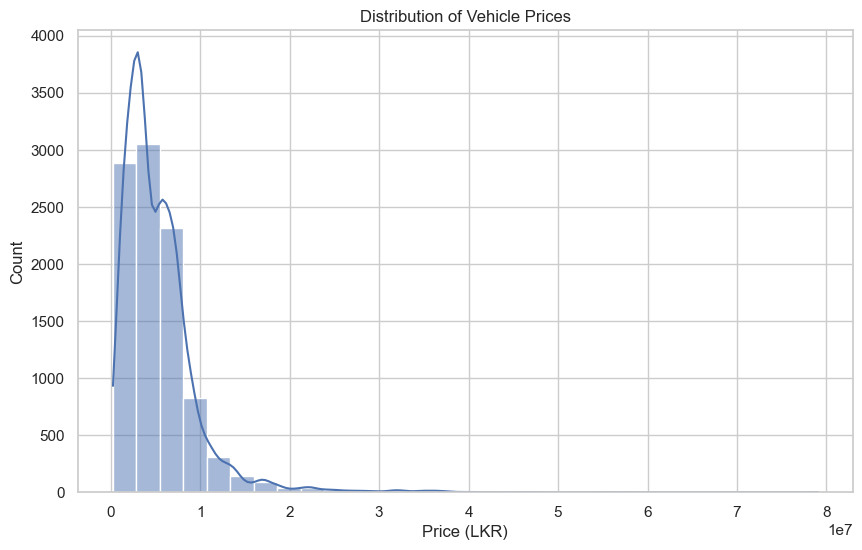

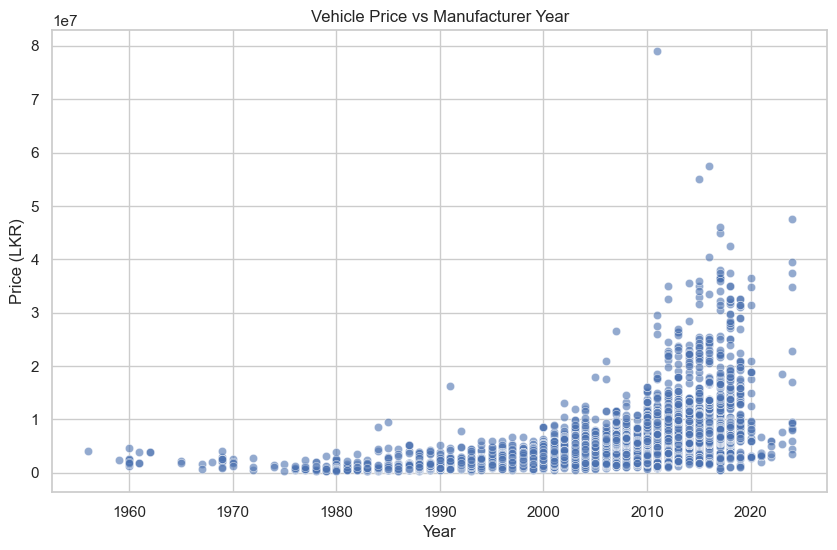

In [12]:
# 1. Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, bins=30)
plt.title('Distribution of Vehicle Prices')
plt.xlabel('Price (LKR)')
plt.show()

# 2. Price vs Manufacturer Year
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Manufacturer Year', y='Price', data=df, alpha=0.6)
plt.title('Vehicle Price vs Manufacturer Year')
plt.xlabel('Year')
plt.ylabel('Price (LKR)')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38548\148387250.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_encoded.select_dtypes(include=['object']).columns:


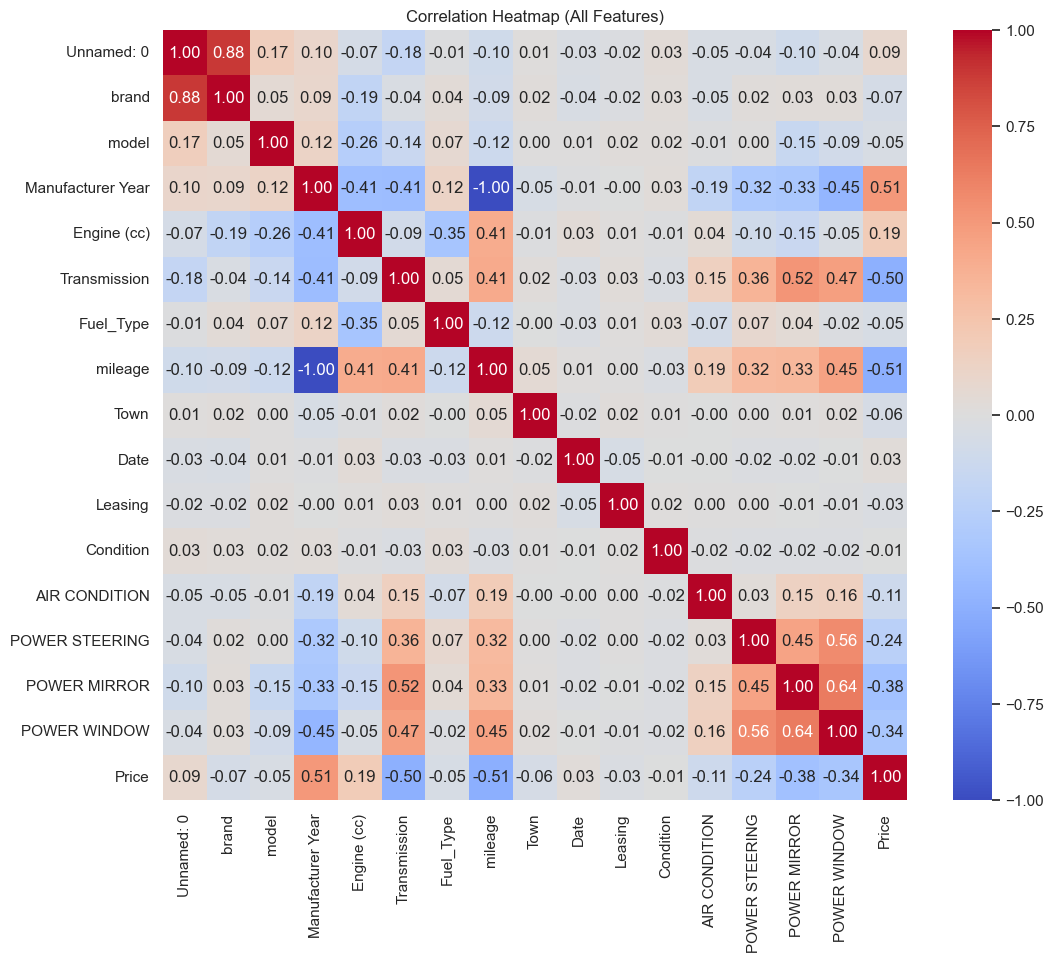

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38548\148387250.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_models.values, y=top_models.index, palette='viridis')


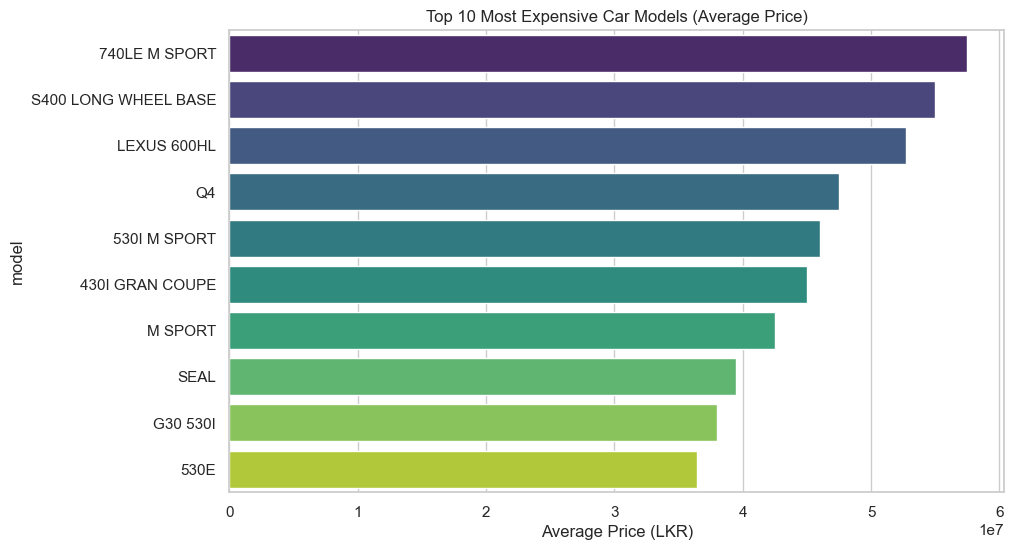

In [6]:
# 4. Correlation Heatmap (Including Categorical Features)
# Encode categorical columns to include them in the correlation matrix
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
label_encoders = {}
for column in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column].astype(str))
    label_encoders[column] = le

corr_matrix = df_encoded.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (All Features)')
plt.show()

# 5. Top 10 Most Expensive Models
if 'model' in df.columns: # standardized lower case name
    top_models = df.groupby('model')['Price'].mean().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_models.values, y=top_models.index, palette='viridis')
    plt.title('Top 10 Most Expensive Car Models (Average Price)')
    plt.xlabel('Average Price (LKR)')
    plt.show()
elif 'Model' in df.columns:
    top_models = df.groupby('Model')['Price'].mean().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_models.values, y=top_models.index, palette='viridis')
    plt.title('Top 10 Most Expensive Car Models (Average Price)')
    plt.xlabel('Average Price (LKR)')
    plt.show()

In [7]:
import joblib
import shap
from sklearn.metrics import mean_squared_error, r2_score

# Load Model and Encoders
try:
    model = joblib.load('models/lgbm_model.pkl')
    encoders = joblib.load('models/encoders.pkl')
    print("Model and Encoders loaded successfully.")
except FileNotFoundError:
    print("Model files not found. Please run 'main.py' first to train the model.")

# Prepare Data for Prediction (Replicate Training Preprocessing)
df_model = df.copy()

# 1. Feature Engineering
current_year = 2026
df_model['vehicle_age'] = current_year - df_model['Manufacturer Year']
# Handle potential division by zero
df_model['vehicle_age'] = df_model['vehicle_age'].replace(0, 1) 
df_model['mileage_per_year'] = df_model['mileage'] / df_model['vehicle_age']

# Rename/Map columns to match training features
# Training features: ['year', 'mileage', 'engine_cc', 'vehicle_age', 'mileage_per_year', 
#                     'brand', 'model', 'fuel_type', 'transmission', 'location', 'condition']
# We need 'engine_cc', 'location', 'condition' which might be named differently or missing
# Check CSV columns: ['Bran', 'Model', 'Manufacturer Year', 'Engine (cc)', 'Transmission', 'Fuel_Type', 'mileage', 'Town', 'Condition']

feature_mapping = {
    'Manufacturer Year': 'year',
    'Engine (cc)': 'engine_cc',
    'Town': 'location', 
    'Condition': 'condition',
    'Transmission': 'transmission',
    'Fuel_Type': 'fuel_type',
    'brand': 'brand',
    'model': 'model',
    'mileage': 'mileage'
}

# Rename available columns
df_model.rename(columns=feature_mapping, inplace=True)

# Ensure numeric columns
numeric_cols = ['year', 'mileage', 'engine_cc', 'vehicle_age', 'mileage_per_year']
for col in numeric_cols:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Drop rows with NaN in critical numeric features
df_model.dropna(subset=['year', 'mileage', 'price_lkr'] if 'price_lkr' in df_model.columns else ['year', 'mileage', 'Price'], inplace=True)
target = df_model['price_lkr'] if 'price_lkr' in df_model.columns else df_model['Price']

# Encode Categorical Variables using loaded encoders
categorical_features = ['brand', 'model', 'fuel_type', 'transmission', 'location', 'condition']

for feature in categorical_features:
    if feature in df_model.columns:
        # Use safe encoding: if label not in encoder, set to unknown/mode (0)
        le = encoders[feature]
        # Convert to string to match encoder expectation
        df_model[feature] = df_model[feature].astype(str)
        
        # Apply transformation with handling for unseen labels
        # Create a set of known classes
        known_classes = set(le.classes_)
        # Apply lambda: map known to transform, unknown to 0 (or some default index if 0 is valid)
        # Note: robust way is to use a dedicated function
        def encode_safe(x):
            return le.transform([x])[0] if x in known_classes else 0 # defaulting to 0 index
        
        df_model[feature] = df_model[feature].apply(encode_safe)

# Select exact columns used in training
train_columns = ['year', 'mileage', 'engine_cc', 'vehicle_age', 'mileage_per_year', 
                 'brand', 'model', 'fuel_type', 'transmission', 'location', 'condition']

# Handle missing columns (e.g. if 'Condition' was missing in CSV)
for col in train_columns:
    if col not in df_model.columns:
        df_model[col] = 0 # Default fill

X = df_model[train_columns]
y_actual = target

print("Features ready for prediction:", X.shape)

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model and Encoders loaded successfully.
Features ready for prediction: (9788, 11)


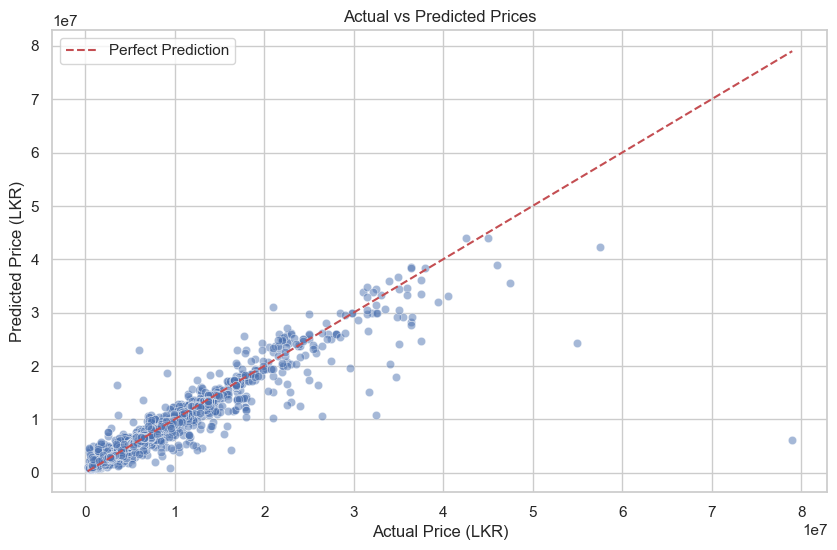

Root Mean Squared Error: 1,272,985.91
R² Score: 0.9148


In [8]:
# 01. Actual Price vs Predicted Price
# Generate predictions (Log-transformed prediction -> Inverse Transform)
y_pred_log = model.predict(X)
y_pred = np.expm1(y_pred_log)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_actual, y=y_pred, alpha=0.5)
# Plot ideal line
max_val = max(y_actual.max(), y_pred.max())
min_val = min(y_actual.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Price (LKR)')
plt.ylabel('Predicted Price (LKR)')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.grid(True)
plt.show()

# Calculate Metrics
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual, y_pred)

print(f"Root Mean Squared Error: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38548\2613304223.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


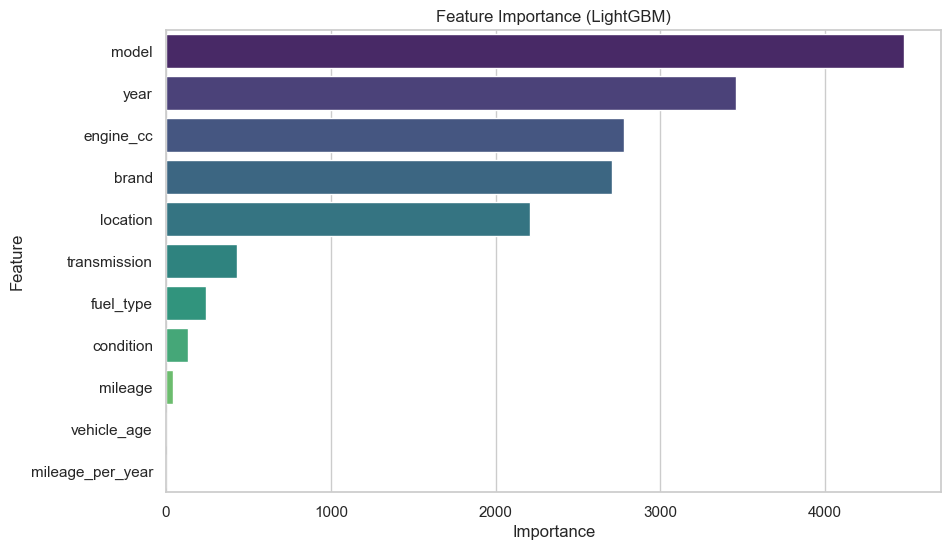

In [9]:
# 02. Top Feature Importance
plt.figure(figsize=(10, 6))
importances = model.feature_importances_
feature_names = X.columns

# Create DataFrame for plotting
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance (LightGBM)')
plt.show()

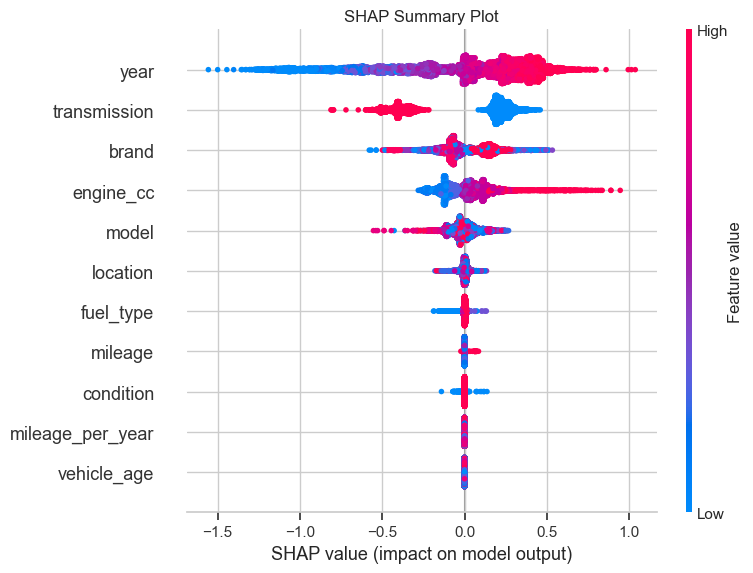

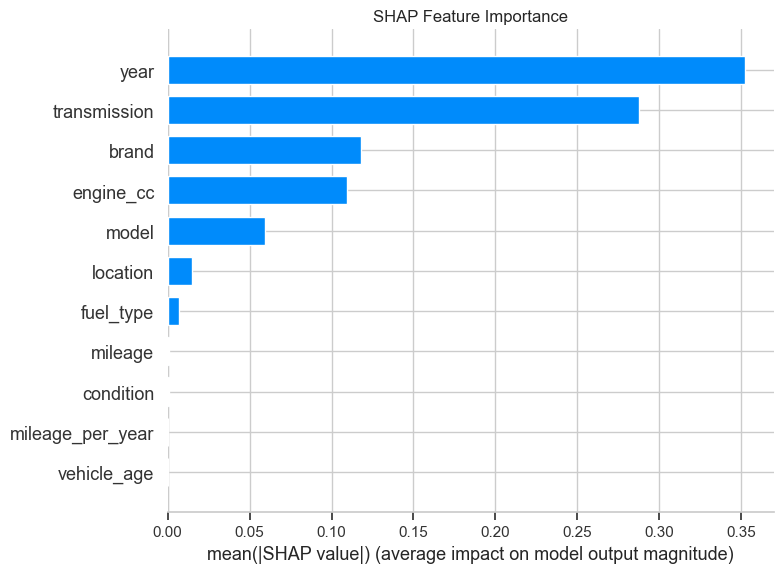

In [10]:
# 03. SHAP Values
# Calculate SHAP values (might take a moment for large datasets)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Summary Plot
plt.title('SHAP Summary Plot')
shap.summary_plot(shap_values, X)

# Bar plot of mean absolute SHAP values
plt.title('SHAP Feature Importance')
shap.summary_plot(shap_values, X, plot_type="bar")

In [13]:
# Display Actual Values for Feature Importance

# 1. SHAP Importance Values
# For regression, shap_values is an array (samples x features). 
# We take the mean of absolute values to get global importance.
mean_shap_values = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean_SHAP_Value': mean_shap_values
}).sort_values(by='Mean_SHAP_Value', ascending=False)

print("\n--- SHAP Feature Importance Values ---")
print(shap_importance_df)

# 2. Model Feature Importance (Split/Gain)
# LightGBM default is 'split' (number of times feature is used). 
# You can also check 'gain' if the model was trained with importance_type='gain'.
model_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Model_Importance': model.feature_importances_
}).sort_values(by='Model_Importance', ascending=False)

print("\n--- LightGBM Model Feature Importance ---")
print(model_importance_df)


--- SHAP Feature Importance Values ---
             Feature  Mean_SHAP_Value
0               year         0.352307
8       transmission         0.287360
5              brand         0.117708
2          engine_cc         0.109521
6              model         0.059250
9           location         0.014622
7          fuel_type         0.007052
1            mileage         0.000780
10         condition         0.000682
3        vehicle_age         0.000000
4   mileage_per_year         0.000000

--- LightGBM Model Feature Importance ---
             Feature  Model_Importance
6              model              4480
0               year              3457
2          engine_cc              2779
5              brand              2704
9           location              2210
8       transmission               429
7          fuel_type               242
10         condition               130
1            mileage                39
3        vehicle_age                 0
4   mileage_per_year            